## Import packages

In [ ]:
from openai import OpenAI
import pandas as pd
from tqdm import tqdm
import pickle
import numpy as np
from sentence_transformers import SentenceTransformer
import pickle
import ast
import pandas as pd
from collections import defaultdict
from utils import prompt, prompt_synthesize, system_prompt, system_prompt_synthesize
from utils import get_topic, synthesize_topic, extract_topics, get_mean_st

model = SentenceTransformer("all-MiniLM-L6-v2")
client = OpenAI(api_key='YOUR_API_KEY',)

/Users/heweiqing/opt/anaconda3/envs/watermark/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Run Experiments

### GPT-methods

In [29]:
# Load the baseline results
with open('../baseline_topics.pkl', 'rb') as f:
    data = pickle.load(f)
# Load the original tweets(after pre-processing)
df = pd.read_csv('../positive-no-spam.csv')
text = df['text'].tolist()

#### Running API

In [ ]:
k = 1
topic_num = 13
result = {}
chunk_size = 1000
gpt_responses = []
# current_len = len(gpt_responses)
for i in tqdm(range(0, len(text), chunk_size)):
    chunk = text[i:i + chunk_size]
    chunk_text = '\n\n'.join(chunk)
    response = get_topic(chunk_text, prompt, topic_num=topic_num)
    gpt_responses.append(response)

print('Finish stage 1 processing')
print('='*50)
print('Start stage 2 processing')
print('='*50)
gpt_responses_input = '\n\n\n'.join(gpt_responses[:100])
final_results_og = synthesize_topic(gpt_responses_input, prompt_synthesize, topic_num=topic_num)
print(final_results_og)
print(f'Sentence-Transformer score: {get_mean_st([final_results_og])}')
result['stage1'] = gpt_responses
result['final'] = final_results_og

with open(f'results/gpt-4o-run{k}_topic{topic_num}.pkl', 'wb') as f:
    pickle.dump(result, f)

Sentence-Transformer score: 0.3568166494369507


In [ ]:
gpt_scores = []
for k in range(2, 6):
    with open(f'results/gpt-4o-run{k}.pkl', 'rb') as f:
        result = pickle.load(f)

    final_results = result['final']
    gpt_scores.append(get_mean_st([final_results]))
gpt_scores.append(0.358) # the first run is 0.358
print("All GPT scores:", [f"{score:.3f}" for score in gpt_scores])
print('Average GPT score: ', f"{np.mean(gpt_scores):.3f}")
# get 90% confidence interval
print('90% confidence interval: ', np.percentile(gpt_scores, [5, 95]))

All GPT scores: ['0.355', '0.359', '0.377', '0.361', '0.358']
Average GPT score:  0.362
90% confidence interval:  [0.35529732 0.37412104]


### Baseline

In [15]:
baseline_folder = 'baseline'
baseline_list = ['baseline_gsdmm',
 'baseline_lda',
 'bdc_gsdmm',
 'bdc_lda',
 'bertopic_distl_roberta',
 'bertopic_minilm',
 'bertopic_mpnet',
 'log_bdc_gsdmm',
 'log_bdc_lda',
 'log_gsdmm',
 'log_lda']
random_seeds = [0,1,42,1234,2025]
all_baseline = {}
for random_seed in random_seeds:
    baseline = {}
    for method in baseline_list:
        temp_dict = {}
        data = pd.read_csv(f'results/{baseline_folder}/{method}_topn_df_5_random{random_seed}.csv')
        for index, row in data.iterrows():
            temp_dict[row['Topic ID']] = ast.literal_eval(row['Topic Top Words'])
        if method == 'log_bdc_gsdmm':
            for key, value in temp_dict.items():
                temp_dict[key] = list(value.keys())
        baseline[method] = temp_dict
    all_baseline[random_seed] = baseline

In [16]:
baseline_sim_dict_transformer = defaultdict(list)
random_seeds = [0,1,42,1234,2025]
for random_seed in random_seeds:
    for keys, values in all_baseline[random_seed].items():
        score = 0
        for subkeys, subvalues in values.items():
            words_list = subvalues
            embeddings = model.encode(words_list)
            similarities = model.similarity(embeddings, embeddings)
            sim = average_pairwise_similarity(similarities)
            score += sim
        baseline_sim_dict_transformer[keys].append(score / len(values))

In [10]:
for key, values in baseline_sim_dict_transformer.items():
    print('Method: ', key)
    print('Average score: ', np.mean(values))
    print('Standard deviation: ', np.std(values))
    print('90% confidence interval: ', np.percentile(values, [5, 95]))
    print('='*50)

Method:  baseline_gsdmm
Average score:  0.31192670464515687
Standard deviation:  0.003726597493350622
90% confidence interval:  [0.30647857 0.31572078]
Method:  baseline_lda
Average score:  0.318034702539444
Standard deviation:  0.001350982041794902
90% confidence interval:  [0.31625445 0.31953995]
Method:  bdc_gsdmm
Average score:  0.29063628554344173
Standard deviation:  0.0015701428378507853
90% confidence interval:  [0.28844154 0.29199881]
Method:  bdc_lda
Average score:  0.28605828404426575
Standard deviation:  0.010526746039264671
90% confidence interval:  [0.27196579 0.29926522]
Method:  bertopic_distl_roberta
Average score:  0.2915398263931274
Standard deviation:  0.004298275598213253
90% confidence interval:  [0.28583695 0.29616342]
Method:  bertopic_minilm
Average score:  0.2998122876882553
Standard deviation:  0.004217641979557033
90% confidence interval:  [0.29369081 0.30429231]
Method:  bertopic_mpnet
Average score:  0.2863162910938263
Standard deviation:  0.00331240810798

## P-values

In [ ]:
from collections import defaultdict
from math import isnan
import numpy as np

from scipy.stats import ttest_rel, ttest_ind, wilcoxon  # pip install scipy if needed

def benjamini_hochberg(pvals):
    """Simple BH-FDR (two-stage not needed here). Returns array of adjusted p-values."""
    m = len(pvals)
    order = np.argsort(pvals)
    ranked = np.array(pvals)[order]
    adj = np.empty(m, dtype=float)
    # Compute adjusted p = p_i * m / rank
    adj_vals = ranked * m / (np.arange(m) + 1)
    # Enforce monotonicity (non-increasing when moving to smaller p)
    adj_vals = np.minimum.accumulate(adj_vals[::-1])[::-1]
    # Cap at 1
    adj_vals = np.minimum(adj_vals, 1.0)
    adj[order] = adj_vals
    return adj.tolist()

def compare_methods(baselines, gpt_scores, paired=True):
    results = []
    gpt_scores = np.asarray(gpt_scores, dtype=float)

    for name, base_scores in baselines.items():
        base_scores = np.asarray(base_scores, dtype=float)

        # Sanity checks
        if paired and len(base_scores) != len(gpt_scores):
            raise ValueError(
                f"Paired test requires equal lengths; got {len(base_scores)} vs {len(gpt_scores)} for {name}"
            )

        # Main test
        if paired:
            t_stat, p_t = ttest_rel(gpt_scores, base_scores, alternative="two-sided")
        else:
            # Welch’s t-test (unequal variances)
            t_stat, p_t = ttest_ind(gpt_scores, base_scores, equal_var=False, alternative="two-sided")

        # Nonparametric paired check (only meaningful if paired and >0 nonzero diffs)
        p_w = np.nan
        if paired:
            diffs = gpt_scores - base_scores
            if np.any(diffs != 0):
                try:
                    # zero_method="wilcox" is standard; fall back if all equal (unlikely)
                    w_stat, p_w = wilcoxon(gpt_scores, base_scores, zero_method="wilcox", alternative="two-sided")
                except ValueError:
                    p_w = np.nan

        # Effect sizes
        mean_gpt = float(np.mean(gpt_scores))
        mean_base = float(np.mean(base_scores))
        diff = mean_gpt - mean_base

        # Cohen's d for paired = mean(diff)/sd(diff)
        if paired:
            diffs = gpt_scores - base_scores
            sd_diff = float(np.std(diffs, ddof=1)) if len(diffs) > 1 else np.nan
            d_cohen = (diff / sd_diff) if (sd_diff and not isnan(sd_diff) and sd_diff != 0) else np.nan
        else:
            # Welch (pooled with unequal var; report Hedges’ g-ish approx)
            n1, n2 = len(gpt_scores), len(base_scores)
            s1, s2 = np.var(gpt_scores, ddof=1), np.var(base_scores, ddof=1)
            # Glass’s Δ (relative to baseline) can be more stable with tiny n
            d_cohen = diff / (np.sqrt(s2) if s2 > 0 else np.nan)

        results.append({
            "baseline": name,
            "mean_gpt": round(mean_gpt, 6),
            "mean_baseline": round(mean_base, 6),
            "mean_diff": round(diff, 6),
            "t_stat": round(float(t_stat), 6) if t_stat is not None else np.nan,
            "p_ttest": float(p_t),
            "p_wilcoxon": float(p_w) if not isnan(p_w) else np.nan,
            "cohen_d": round(float(d_cohen), 6) if d_cohen is not None and not isnan(d_cohen) else np.nan,
            "n": int(len(base_scores))
        })

    # FDR across all t-test p-values
    pvals = [r["p_ttest"] for r in results]
    p_adj = benjamini_hochberg(pvals)
    for r, padj in zip(results, p_adj):
        r["p_ttest_fdr"] = float(padj)

    # Sort by adjusted p ascending
    results.sort(key=lambda r: r["p_ttest_fdr"])
    return results

# --- Run ---
# Set paired=True if each run corresponds to the same seeds/folds across methods.
# Otherwise set paired=False to use Welch's t-test.
paired = True
summary = compare_methods(baseline_sim_dict_transformer, gpt_scores, paired=paired)

# Pretty print
from pprint import pprint
pprint(summary)


[{'baseline': 'bertopic_distl_roberta',
  'cohen_d': 8.395792,
  'mean_baseline': 0.29154,
  'mean_diff': 0.070435,
  'mean_gpt': 0.361975,
  'n': 5,
  'p_ttest': 4.740172110732935e-05,
  'p_ttest_fdr': 0.00023387742553513302,
  'p_wilcoxon': 0.0625,
  't_stat': 18.773561},
 {'baseline': 'bertopic_mpnet',
  'cohen_d': 7.789375,
  'mean_baseline': 0.286316,
  'mean_diff': 0.075659,
  'mean_gpt': 0.361975,
  'n': 5,
  'p_ttest': 6.378475241867264e-05,
  'p_ttest_fdr': 0.00023387742553513302,
  'p_wilcoxon': 0.0625,
  't_stat': 17.417572},
 {'baseline': 'log_bdc_lda',
  'cohen_d': 9.114597,
  'mean_baseline': 0.264754,
  'mean_diff': 0.097221,
  'mean_gpt': 0.361975,
  'n': 5,
  'p_ttest': 3.422339837266744e-05,
  'p_ttest_fdr': 0.00023387742553513302,
  'p_wilcoxon': 0.0625,
  't_stat': 20.380858},
 {'baseline': 'bdc_gsdmm',
  'cohen_d': 6.951245,
  'mean_baseline': 0.290636,
  'mean_diff': 0.071339,
  'mean_gpt': 0.361975,
  'n': 5,
  'p_ttest': 0.00010001633232482186,
  'p_ttest_fdr': 

*Here since for every run our method outperform the baseline, so the p-value is very low.*

## Plots

In [20]:
score_dic = {}
score_dic['GSDMM'] = baseline_sim_dict_transformer['baseline_gsdmm']
score_dic['LDA'] = baseline_sim_dict_transformer['baseline_lda']
score_dic['BDC-GSDMM'] = baseline_sim_dict_transformer['bdc_gsdmm']
score_dic['BDC-LDA'] = baseline_sim_dict_transformer['bdc_lda']
score_dic['BERTopic-Distl'] = baseline_sim_dict_transformer['bertopic_distl_roberta']
score_dic['BERTopic-MiniLM'] = baseline_sim_dict_transformer['bertopic_minilm']
score_dic['BERTopic-MPNET'] = baseline_sim_dict_transformer['bertopic_mpnet']
score_dic['Log-BDC-GSDMM'] = baseline_sim_dict_transformer['log_bdc_gsdmm']
score_dic['Log-BDC-LDA'] = baseline_sim_dict_transformer['log_bdc_lda']
score_dic['Log-GSDMM'] = baseline_sim_dict_transformer['log_gsdmm']
score_dic['Log-LDA'] = baseline_sim_dict_transformer['log_lda']
score_dic['GPT-based'] = gpt_scores

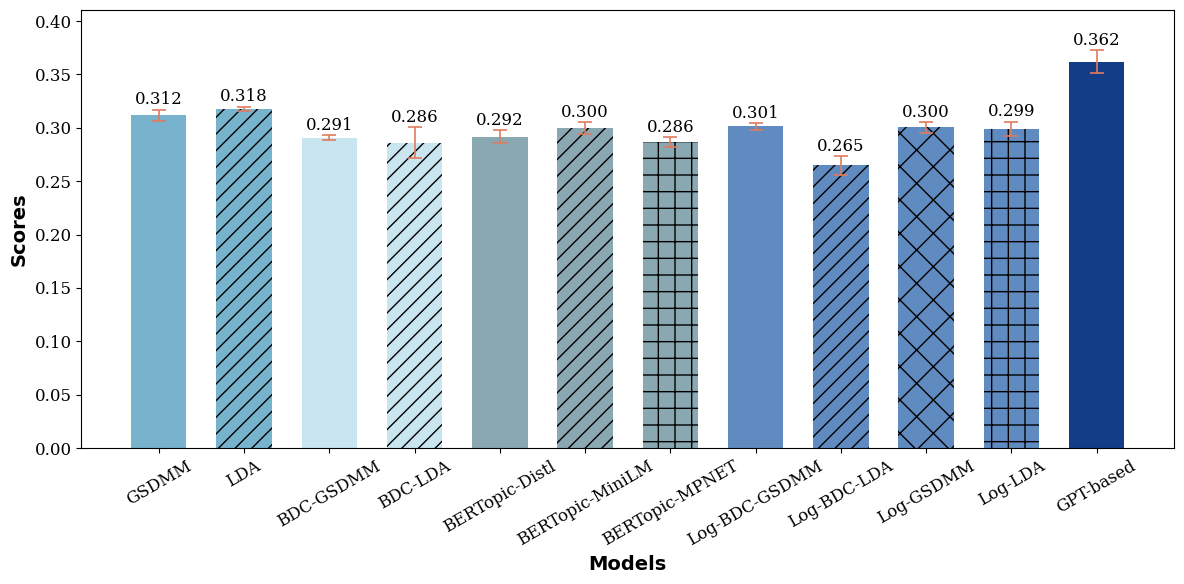

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from itertools import islice, cycle

# Figure setup
fig, ax = plt.subplots(figsize=(12, 6))
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

models = list(score_dic.keys())
runs_lists = [np.asarray(score_dic[m], dtype=float) for m in models]

# Compute means and 95% CIs (two-sided, t-based)
means, ci95 = [], []
for arr in runs_lists:
    n = len(arr)
    mean = float(np.mean(arr))
    if n > 1:
        sd = float(np.std(arr, ddof=1))
        tcrit = stats.t.ppf(0.975, df=n-1)  # two-sided 95% CI
        half_width = tcrit * sd / np.sqrt(n)
    else:
        half_width = 0.0
    means.append(mean)
    ci95.append(half_width)

# Colors & hatches (cycled if you have fewer/more models)
colors_and_patterns = [
    ('#78B3CE', ''),   # GSDMM
    ('#78B3CE', '//'), # LDA
    ('#C9E6F0', ''),   # BDC-GSDMM
    ('#C9E6F0', '//'), # BDC-LDA
    ('#89A8B2', ''),   # BERTopic-Distl-RoBERTa
    ('#89A8B2', '//'), # BERTopic-MiniLM
    ('#89A8B2', '+'),  # BERTopic-MPNET
    ('#608BC1', ''),   # Log-BDC-GSDMM
    ('#608BC1', '//'), # Log-BDC-LDA
    ('#608BC1', 'x'),  # Log-GSDMM
    ('#608BC1', '+'),  # Log-LDA
    ('#133E87', '')    # GPT-based
]

# If your models list is shorter/longer, cycle the style list safely
style_iter = islice(cycle(colors_and_patterns), len(models))

bar_width = 0.65
bars = []
for (model, mean, ci), (color, hatch) in zip(zip(models, means, ci95), style_iter):
    b = ax.bar(model, mean, yerr=ci, capsize=5,
               color=color, hatch=hatch,
               label=model if hatch == '' else "",
               width=bar_width, linewidth=0.8,
               error_kw=dict(ecolor="#E07A5F", elinewidth=1.2, capthick=1.2))
    bars.append(b)
    # Annotate mean above the (mean + CI) tip
    ax.text(b[0].get_x() + b[0].get_width() / 2,
            mean + ci + 0.001,
            f'{mean:.3f}',
            ha='center', va='bottom')

# Y limits with headroom above the tallest CI
upper = max(m + c for m, c in zip(means, ci95))
ax.set_ylim(0, max(0.4, upper * 1.10))  # keep your 0.4 ceiling if it’s higher than needed

# Labels & ticks
ax.set_xlabel("Models", fontsize=14, fontweight='bold', fontfamily='sans-serif')
ax.set_ylabel("Scores", fontsize=14, fontweight='bold', fontfamily='sans-serif')
ax.tick_params(axis='x', rotation=30, labelsize=12)

# Optional: show a legend for the models whose bars have no hatch (to avoid duplicates)
handles, labels = ax.get_legend_handles_labels()
# if labels:
#     ax.legend(handles, labels, frameon=False, loc='best')

plt.tight_layout()
plt.show()

# Save the plot
fig.savefig('plots/mean_scores_with_ci.png', dpi=400)


## Coherence score

*Note: This part of code if borrowed from the work: Analyzing Dementia Caregivers’ Experiences on Twitter: A Term-Weighted Topic Modeling Approach*

In [33]:
from gpt_topic_coherence import load_texts_and_dictionary, evaluate_gpt_topics

In [84]:
gpt_coherence = []
for k in tqdm(range(2, 7)):
    with open(f'results/gpt-4o-run{k}.pkl', 'rb') as f:
        result = pickle.load(f)
    gpt_responses = [result['final']]
    all_topics_words = []
    for i in range(len(gpt_responses)):
        extracted_data = extract_topics(gpt_responses[i])
    for keys, values in extracted_data.items():
        words_list = values['Words']
        all_topics_words.append(words_list)
    
    texts, dictionary = load_texts_and_dictionary(
        '../baseline/Twitter_Text_Data/positives_tokens.pkl',
        '../baseline/Twitter_Text_Data/positives_dictionary.pkl'
    )
    
        # Evaluate topics using your actual data
    results = evaluate_gpt_topics(all_topics_words, texts, dictionary)
    gpt_coherence.append(results['c_v']['model_score'])

  0%|          | 0/5 [00:00<?, ?it/s]

Loading texts from: ../baseline/Twitter_Text_Data/positives_tokens.pkl
Loading dictionary from: ../baseline/Twitter_Text_Data/positives_dictionary.pkl
Loaded 224862 documents
Dictionary contains 36482 unique tokens

Evaluating with c_v coherence
Topic coherence type: c_v
Number of topics: 5
Calculating coherence for topic 0: ['heartbreaking', 'sadness', 'grief', 'tears', 'sorrow']...
Calculating coherence for topic 1: ['forget', 'remember', 'recognize', 'recall', 'memory']...
Calculating coherence for topic 2: ['mother', 'father', 'grandmother', 'grandfather', 'sister']...
Calculating coherence for topic 3: ['feeding', 'bathing', 'dressing', 'medication', 'routine']...
Calculating coherence for topic 4: ['patience', 'resilience', 'acceptance', 'adaptation', 'mindfulness']...
Calculating overall model coherence...

Results for c_v:
Model coherence score: 0.5034
Mean topic coherence: 0.6649 ± 0.0533
Individual topic scores: ['0.5716', '0.6568', '0.6842', '0.6769', '0.7351']

Evaluating w

 20%|██        | 1/5 [00:22<01:29, 22.30s/it]


Results for u_mass:
Model coherence score: -13.5982
Mean topic coherence: -13.5982 ± 2.6413
Individual topic scores: ['-8.7766', '-13.2898', '-13.9971', '-16.2711', '-15.6564']
Loading texts from: ../baseline/Twitter_Text_Data/positives_tokens.pkl
Loading dictionary from: ../baseline/Twitter_Text_Data/positives_dictionary.pkl
Loaded 224862 documents
Dictionary contains 36482 unique tokens

Evaluating with c_v coherence
Topic coherence type: c_v
Number of topics: 5
Calculating coherence for topic 0: ['heartbreaking', 'sadness', 'grief', 'tears', 'sorrow']...
Calculating coherence for topic 1: ['forget', 'remember', 'recognize', 'recall', 'memory']...
Calculating coherence for topic 2: ['feeding', 'bathing', 'dressing', 'medication', 'routine']...
Calculating coherence for topic 3: ['family', 'mother', 'father', 'grandmother', 'grandfather']...
Calculating coherence for topic 4: ['patience', 'resilience', 'strength', 'hope', 'acceptance']...
Calculating overall model coherence...

Resul

 40%|████      | 2/5 [00:43<01:04, 21.50s/it]

...


Results for u_mass:
Model coherence score: -13.0057
Mean topic coherence: -13.0057 ± 2.6171
Individual topic scores: ['-8.4342', '-14.7205', '-11.7321', '-14.7141', '-15.4277']
Loading texts from: ../baseline/Twitter_Text_Data/positives_tokens.pkl
Loading dictionary from: ../baseline/Twitter_Text_Data/positives_dictionary.pkl
Loaded 224862 documents
Dictionary contains 36482 unique tokens

Evaluating with c_v coherence
Topic coherence type: c_v
Number of topics: 5
Calculating coherence for topic 0: ['heartbreaking', 'devastating', 'overwhelming', 'exhausting', 'frustrating']...
Calculating coherence for topic 1: ['forget', 'remember', 'recognize', 'recall', 'memory']...
Calculating coherence for topic 2: ['mother', 'father', 'grandmother', 'grandfather', 'sister']...
Calculating coherence for topic 3: ['feeding', 'bathing', 'dressing', 'assisting', 'helping']...
Calculating coherence for topic 4: ['patience', 'resilience', 'strength', 'hope', 'acceptance']...
Calculating overall model

 80%|████████  | 4/5 [01:27<00:22, 22.03s/it]


Results for u_mass:
Model coherence score: -14.6947
Mean topic coherence: -14.6947 ± 1.1180
Individual topic scores: ['-12.6562', '-14.5080', '-15.4184', '-14.9937', '-15.8972']
Loading texts from: ../baseline/Twitter_Text_Data/positives_tokens.pkl
Loading dictionary from: ../baseline/Twitter_Text_Data/positives_dictionary.pkl
Loaded 224862 documents
Dictionary contains 36482 unique tokens

Evaluating with c_v coherence
Topic coherence type: c_v
Number of topics: 5
Calculating coherence for topic 0: ['heartbreaking', 'sadness', 'grief', 'tears', 'sorrow']...
Calculating coherence for topic 1: ['forget', 'remember', 'recognize', 'recall', 'memory']...
Calculating coherence for topic 2: ['mother', 'father', 'grandmother', 'grandfather', 'sister']...
Calculating coherence for topic 3: ['feeding', 'bathing', 'dressing', 'cleaning', 'cooking']...
Calculating coherence for topic 4: ['patience', 'resilience', 'strength', 'hope', 'acceptance']...
Calculating overall model coherence...

Result

100%|██████████| 5/5 [01:52<00:00, 22.42s/it]


Results for u_mass:
Model coherence score: -13.5888
Mean topic coherence: -13.5888 ± 1.7170
Individual topic scores: ['-10.4797', '-14.1056', '-13.1593', '-14.9302', '-15.2693']


In [88]:
# Here use one of the baseline result
coherence_score_dic = defaultdict(list)
seeds = [0, 1, 42, 1234, 2025]
for seed in seeds:
    baseline_coherence_df = pd.read_csv(f'results/baseline/score_df_5_random{seed}.csv')
    coherence_dict = dict(zip(baseline_coherence_df["Model"], baseline_coherence_df["Coherence"]))
    coherence_score_dic['GSDMM'].append(coherence_dict['baseline_gsdmm'])
    coherence_score_dic['LDA'].append(coherence_dict['baseline_lda'])
    coherence_score_dic['BDC-GSDMM'].append(coherence_dict['bdc_gsdmm'])
    coherence_score_dic['BDC-LDA'].append(coherence_dict['bdc_lda'])
    coherence_score_dic['BERTopic-Distl'].append(coherence_dict['bertopic_distl_roberta'])
    coherence_score_dic['BERTopic-MiniLM'].append(coherence_dict['bertopic_minilm'])
    coherence_score_dic['BERTopic-MPNET'].append(coherence_dict['bertopic_mpnet'])
    coherence_score_dic['Log-BDC-GSDMM'].append(coherence_dict['log_bdc_gsdmm'])
    coherence_score_dic['Log-BDC-LDA'].append(coherence_dict['log_bdc_lda'])
    coherence_score_dic['Log-GSDMM'].append(coherence_dict['log_gsdmm'])
    coherence_score_dic['Log-LDA'].append(coherence_dict['log_lda'])

coherence_score_dic['GPT-based'] = gpt_coherence

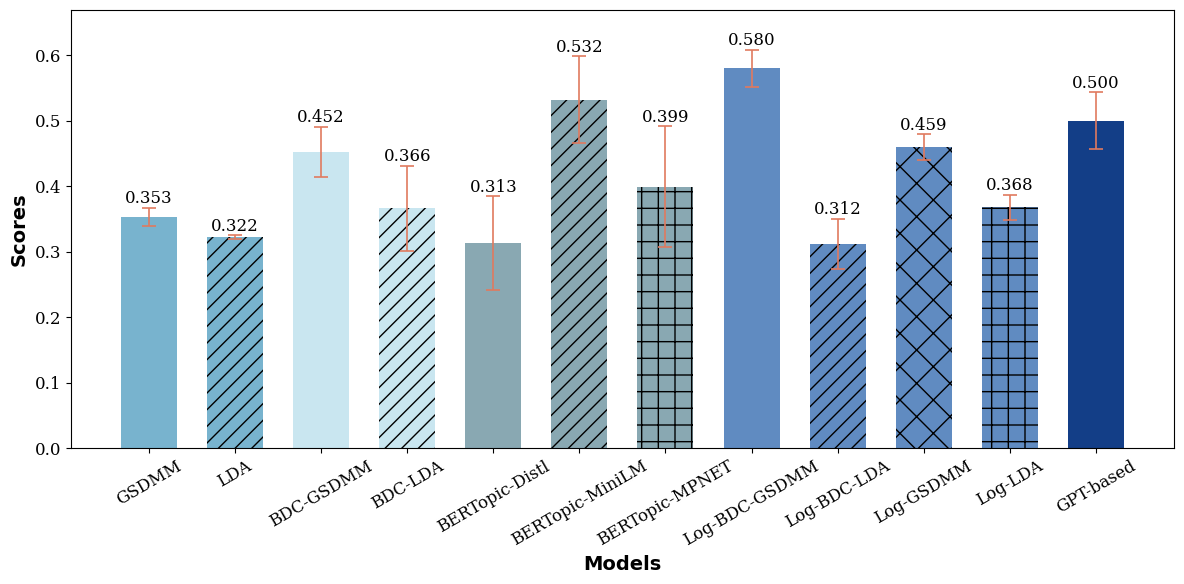

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from itertools import islice, cycle

# Figure setup
fig, ax = plt.subplots(figsize=(12, 6))
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

models = list(coherence_score_dic.keys())
runs_lists = [np.asarray(coherence_score_dic[m], dtype=float) for m in models]

# Compute means and 95% CIs (two-sided, t-based)
means, ci95 = [], []
for arr in runs_lists:
    n = len(arr)
    mean = float(np.mean(arr))
    if n > 1:
        sd = float(np.std(arr, ddof=1))
        tcrit = stats.t.ppf(0.975, df=n-1)  # two-sided 95% CI
        half_width = tcrit * sd / np.sqrt(n)
    else:
        half_width = 0.0
    means.append(mean)
    ci95.append(half_width)

# Colors & hatches (cycled if you have fewer/more models)
colors_and_patterns = [
    ('#78B3CE', ''),   # GSDMM
    ('#78B3CE', '//'), # LDA
    ('#C9E6F0', ''),   # BDC-GSDMM
    ('#C9E6F0', '//'), # BDC-LDA
    ('#89A8B2', ''),   # BERTopic-Distl-RoBERTa
    ('#89A8B2', '//'), # BERTopic-MiniLM
    ('#89A8B2', '+'),  # BERTopic-MPNET
    ('#608BC1', ''),   # Log-BDC-GSDMM
    ('#608BC1', '//'), # Log-BDC-LDA
    ('#608BC1', 'x'),  # Log-GSDMM
    ('#608BC1', '+'),  # Log-LDA
    ('#133E87', '')    # GPT-based
]

# If your models list is shorter/longer, cycle the style list safely
style_iter = islice(cycle(colors_and_patterns), len(models))

bar_width = 0.65
bars = []
for (model, mean, ci), (color, hatch) in zip(zip(models, means, ci95), style_iter):
    b = ax.bar(model, mean, yerr=ci, capsize=5,
               color=color, hatch=hatch,
               label=model if hatch == '' else "",
               width=bar_width, linewidth=0.8,
               error_kw=dict(ecolor="#E07A5F", elinewidth=1.2, capthick=1.2))
    bars.append(b)
    # Annotate mean above the (mean + CI) tip
    ax.text(b[0].get_x() + b[0].get_width() / 2,
            mean + ci + 0.001,
            f'{mean:.3f}',
            ha='center', va='bottom')

# Y limits with headroom above the tallest CI
upper = max(m + c for m, c in zip(means, ci95))
ax.set_ylim(0, max(0.4, upper * 1.10))  # keep your 0.4 ceiling if it’s higher than needed

# Labels & ticks
ax.set_xlabel("Models", fontsize=14, fontweight='bold', fontfamily='sans-serif')
ax.set_ylabel("Scores", fontsize=14, fontweight='bold', fontfamily='sans-serif')
ax.tick_params(axis='x', rotation=30, labelsize=12)

# Optional: show a legend for the models whose bars have no hatch (to avoid duplicates)
handles, labels = ax.get_legend_handles_labels()
# if labels:
#     ax.legend(handles, labels, frameon=False, loc='best')

plt.tight_layout()
plt.show()

# Save the plot
fig.savefig('plots/mean_coherence_scores_with_ci.png', dpi=400)
